### Vérification du device 

In [1]:
import torch 

# Vérification du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cpu


##  1. Hyperparamètres (CONFIG)

In [2]:
from utils import CONFIG

print('Configuration chargée.')
for k, v in CONFIG.items():
    print(f'   {k:<20} = {v}')

 Fonctions utils.py définies.
Configuration chargée.
   model_name           = google-bert/bert-base-multilingual-cased
   max_length           = 256
   dataset_path         = data/inshort_news_data-1-2.csv
   text_column          = news_headline
   article_column       = news_article
   label_column         = news_category
   val_split            = 0.2
   num_epochs           = 4
   batch_size           = 16
   learning_rate        = 3e-05
   weight_decay         = 0.01
   warmup_ratio         = 0.1
   clip_grad            = 1.0
   seed                 = 42
   save_dir             = best_model
   project_wandb        = bert-classification-inshort-news
   run_name             = bert-multilingual-cased-run1


---
##  2. Inspection du Dataset

Avant d'entraîner, il est **indispensable** d'analyser le dataset pour :
- Comprendre la distribution des classes (déséquilibre éventuel)
- Choisir la bonne valeur de `max_length`
- Détecter des anomalies ou textes corrompus

### 2.1 Chargement brut du CSV

In [3]:
import pandas as pd 

# Chargement
df_raw = pd.read_csv(CONFIG['dataset_path'])

print(f"{'═'*60}")
print(f"    INFORMATIONS GÉNÉRALES DU DATASET")
print(f"{'═'*60}")
print(f"  Fichier   : {CONFIG['dataset_path']}")
print(f"  Shape brut: {df_raw.shape}  ({df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes)")
print(f"  Colonnes  : {list(df_raw.columns)}")
print(f"\n  Aperçu des premières lignes :")
df_raw.head()

════════════════════════════════════════════════════════════
    INFORMATIONS GÉNÉRALES DU DATASET
════════════════════════════════════════════════════════════
  Fichier   : data/inshort_news_data-1-2.csv
  Shape brut: (4817, 4)  (4,817 lignes × 4 colonnes)
  Colonnes  : ['Unnamed: 0', 'news_headline', 'news_article', 'news_category']

  Aperçu des premières lignes :


,Unnamed: 0,news_headline,news_article,news_category
0,0,50-year-old problem of biology solved by Artif...,DeepMind's AI system 'AlphaFold' has been reco...,technology
1,1,Microsoft Teams to stop working on Internet Ex...,Microsoft Teams will stop working on Internet ...,technology
2,2,Hope US won't erect barriers to cooperation: C...,"China, in response to reports of US adding Chi...",technology
3,3,Global smartphone sales in Q3 falls 5.7% to 36...,The global smartphone sales in the third quart...,technology
4,4,EU hoping Biden will clarify US position on di...,The European Union (EU) is hoping that US Pres...,technology


### 2.2 Nettoyage et statistiques générales

In [5]:
# Nettoyage
TEXT_COL    = CONFIG['text_column']
ARTICLE_COL = CONFIG['article_column']
LABEL_COL   = CONFIG['label_column']

df = df_raw[[TEXT_COL, ARTICLE_COL, LABEL_COL]].copy()
n_before = len(df)
df = df.dropna()
df[TEXT_COL]    = df[TEXT_COL].astype(str).str.strip()
df[ARTICLE_COL] = df[ARTICLE_COL].astype(str).str.strip()
df[LABEL_COL]   = df[LABEL_COL].astype(str).str.strip()
df = df[(df[TEXT_COL] != '') & (df[ARTICLE_COL] != '')]  # Retire les lignes vides

# Colonne combinée : titre [SEP] article
# On concatène le titre et l'article avec le token séparateur [SEP] de BERT.
# BERT encode naturellement deux segments distincts grâce à token_type_ids.
# Format : "[titre]. [article]" (le tokenizer ajoute [CLS]/[SEP] automatiquement)
COMBINED_COL = 'text_combined'
df[COMBINED_COL] = df[TEXT_COL] + '. ' + df[ARTICLE_COL]

n_after = len(df)

print(f"{'═'*60}")
print(f"   NETTOYAGE")
print(f"{'═'*60}")
print(f"  Lignes avant nettoyage : {n_before:>6,}")
print(f"  Lignes supprimées      : {n_before - n_after:>6,}  (NaN, vides)")
print(f"  Lignes après nettoyage : {n_after:>6,}")

# Nombre de classes
class_names_raw = sorted(df[LABEL_COL].unique())
num_classes     = len(class_names_raw)

print(f"\n{'═'*60}")
print(f"     NOMBRE TOTAL D'EXEMPLES ET DE CLASSES")
print(f"{'═'*60}")
print(f"  Nombre total d'exemples : {n_after:,}")
print(f"  Nombre de classes       : {num_classes}")
print(f"  Classes détectées :")
for i, cls in enumerate(class_names_raw):
    print(f"    [{i}] {cls}")

════════════════════════════════════════════════════════════
   NETTOYAGE
════════════════════════════════════════════════════════════
  Lignes avant nettoyage :  4,817
  Lignes supprimées      :      0  (NaN, vides)
  Lignes après nettoyage :  4,817

════════════════════════════════════════════════════════════
     NOMBRE TOTAL D'EXEMPLES ET DE CLASSES
════════════════════════════════════════════════════════════
  Nombre total d'exemples : 4,817
  Nombre de classes       : 7
  Classes détectées :
    [0] automobile
    [1] entertainment
    [2] politics
    [3] science
    [4] sports
    [5] technology
    [6] world


### 2.3 Distribution des classes & détection du déséquilibre

In [7]:
# Distribution
dist = df[LABEL_COL].value_counts().sort_values(ascending=False)

print(f"{'═'*60}")
print(f"    DISTRIBUTION DES CLASSES")
print(f"{'═'*60}")
print(f"  {'Classe':<22} {'Count':>6}  {'%':>6}  Barre")
print(f"  {'-'*55}")
for cls, cnt in dist.items():
    pct = cnt / n_after * 100
    bar = '█' * int(pct / 2)
    print(f"  {cls:<22} {cnt:>6,}  {pct:>5.1f}%  {bar}")

# Déséquilibre
ratio = dist.max() / dist.min()
print(f"\n  Ratio max/min : {ratio:.2f}x")

if ratio > 2.0:
    print(f"\n DÉSÉQUILIBRE DÉTECTÉ (ratio = {ratio:.1f}x > 2:1)")
    print(f"    Stratégie retenue :")
    print(f"     1. Split STRATIFIÉ (train_test_split avec stratify=labels)")
    print(f"        → Préserve la distribution originale dans chaque split.")
    print(f"     2. Métrique principale : F1-MACRO")
    print(f"        → Donne le même poids à chaque classe indépendamment")
    print(f"          de sa fréquence (évite le biais vers la classe majoritaire).")
    print(f"     3. Pas de sur-échantillonnage ici (BERT fine-tuning tolère")
    print(f"        un déséquilibre modéré grâce au pré-entraînement).")
    print(f"     Si ratio > 10:1, envisager class_weight dans CrossEntropyLoss.")
else:
    print(f"   Dataset ÉQUILIBRÉ (ratio {ratio:.1f}x ≤ 2:1) — pas d'ajustement nécessaire.")

════════════════════════════════════════════════════════════
    DISTRIBUTION DES CLASSES
════════════════════════════════════════════════════════════
  Classe                  Count       %  Barre
  -------------------------------------------------------
  world                   1,021   21.2%  ██████████
  entertainment             998   20.7%  ██████████
  sports                    856   17.8%  ████████
  technology                751   15.6%  ███████
  politics                  546   11.3%  █████
  science                   389    8.1%  ████
  automobile                256    5.3%  ██

  Ratio max/min : 3.99x

 DÉSÉQUILIBRE DÉTECTÉ (ratio = 4.0x > 2:1)
    Stratégie retenue :
     1. Split STRATIFIÉ (train_test_split avec stratify=labels)
        → Préserve la distribution originale dans chaque split.
     2. Métrique principale : F1-MACRO
        → Donne le même poids à chaque classe indépendamment
          de sa fréquence (évite le biais vers la classe majoritaire).
     3. Pas 

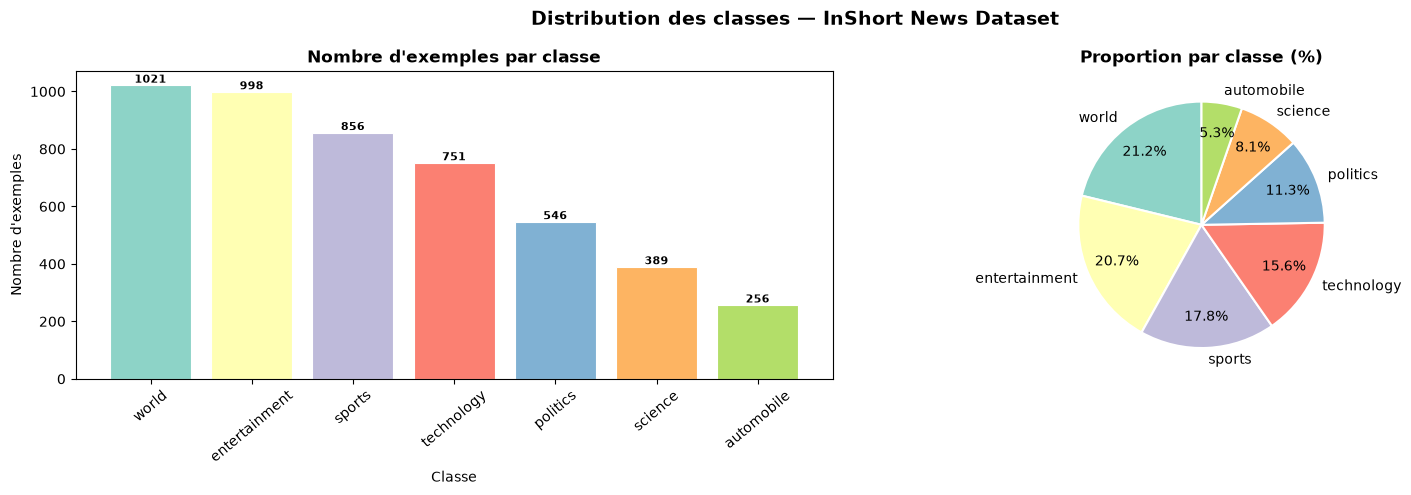

   Graphique sauvegardé → class_distribution_inspection.png


In [8]:
import matplotlib.pyplot as plt 
# Graphique de distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des classes — InShort News Dataset', fontsize=14, fontweight='bold')

# Barplot
colors = plt.cm.Set3.colors[:len(dist)]
bars = axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Nombre d\'exemples par classe', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'exemples')
axes[0].tick_params(axis='x', rotation=40)
for bar, cnt in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Camembert
axes[1].pie(dist.values, labels=dist.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion par classe (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution_inspection.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Graphique sauvegardé → class_distribution_inspection.png')

### 2.4 Longueur des textes (en tokens BERT)

In [9]:
from transformers import AutoTokenizer
    
# Chargement du tokenizer pour mesurer les vraies longueurs BERT
print('      Chargement du tokenizer pour l\'analyse des longueurs...')
_tokenizer_inspect = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'   Tokenizer chargé | Vocab size : {_tokenizer_inspect.vocab_size:,}\n')

# Calcul des longueurs en TOKENS BERT pour les 3 colonnes
print('    Tokenization des 3 colonnes pour l\'analyse (1-2 min)...')
tok_headline = df[TEXT_COL].apply(
    lambda t: len(_tokenizer_inspect.encode(t, add_special_tokens=True))
)
tok_article  = df[ARTICLE_COL].apply(
    lambda t: len(_tokenizer_inspect.encode(t, add_special_tokens=True))
)
tok_combined = df[COMBINED_COL].apply(
    lambda t: len(_tokenizer_inspect.encode(t, add_special_tokens=True))
)
# On utilise la colonne combinée comme référence principale
token_lengths = tok_combined
word_lengths  = df[COMBINED_COL].str.split().str.len()

print(f"\n{'═'*70}")
print(f"    LONGUEUR DES TEXTES (en tokens BERT)")
print(f"{'═'*70}")
print(f"  {'Métrique':<16} {'Titre':>10}  {'Article':>10}  {'Titre+Article':>14}")
print(f"  {'-'*55}")
for label, s_h, s_a, s_c in [
    ('Minimum',      tok_headline.min(),              tok_article.min(),              tok_combined.min()),
    ('Maximum',      tok_headline.max(),              tok_article.max(),              tok_combined.max()),
    ('Moyenne',      tok_headline.mean(),             tok_article.mean(),             tok_combined.mean()),
    ('Médiane (P50)',tok_headline.median(),           tok_article.median(),           tok_combined.median()),
    ('P90',          tok_headline.quantile(0.90),     tok_article.quantile(0.90),     tok_combined.quantile(0.90)),
    ('P95',          tok_headline.quantile(0.95),     tok_article.quantile(0.95),     tok_combined.quantile(0.95)),
    ('P99',          tok_headline.quantile(0.99),     tok_article.quantile(0.99),     tok_combined.quantile(0.99)),
]:
    print(f"  {label:<16} {s_h:>10.0f}  {s_a:>10.0f}  {s_c:>14.0f}")

p95_tokens = tok_combined.quantile(0.95)
print(f"\n    Recommandation max_length (basé sur Titre+Article) :")
print(f"     P95 combiné = {p95_tokens:.0f} tokens → CONFIG['max_length'] = {CONFIG['max_length']}")
if CONFIG['max_length'] >= p95_tokens:
    pct_covered = (tok_combined <= CONFIG['max_length']).mean() * 100
    print(f"       Couvre {pct_covered:.1f}% des paires (titre+article) sans troncature.")
else:
    pct_truncated = (tok_combined > CONFIG['max_length']).mean() * 100
    print(f"        {pct_truncated:.1f}% des paires seront tronquées à {CONFIG['max_length']} tokens.")
    print(f"     → Envisager max_length = {int(p95_tokens) + 4} (arrondi au multiple de 4).")
    print(f"        Note : BERT accepte jusqu\'à 512 tokens max.")

/home/jfo/Documents/python/DL2/bert-classification-test-clean-machine/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


      Chargement du tokenizer pour l'analyse des longueurs...
   Tokenizer chargé | Vocab size : 119,547

    Tokenization des 3 colonnes pour l'analyse (1-2 min)...

══════════════════════════════════════════════════════════════════════
    LONGUEUR DES TEXTES (en tokens BERT)
══════════════════════════════════════════════════════════════════════
  Métrique              Titre     Article   Titre+Article
  -------------------------------------------------------
  Minimum                  10          63              77
  Maximum                  31         144             162
  Moyenne                  19          88             106
  Médiane (P50)            19          87             105
  P90                      24         101             122
  P95                      25         106             128
  P99                      28         115             138

    Recommandation max_length (basé sur Titre+Article) :
     P95 combiné = 128 tokens → CONFIG['max_length'] = 256
       Couv

/tmp/ipykernel_127886/3794437883.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=LABEL_COL, y='tok_combined', ax=axes[1],


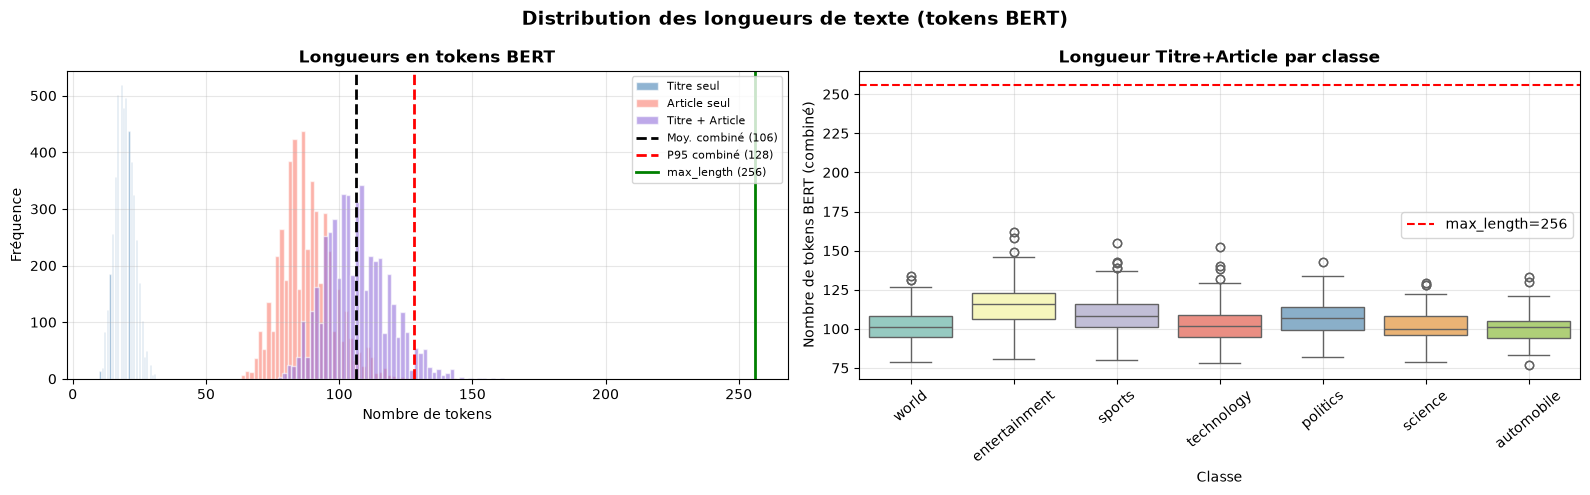

  Graphique sauvegardé → token_length_distribution.png


In [10]:
import seaborn as sns

# Histogramme des longueurs (3 colonnes superposées)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des longueurs de texte (tokens BERT)', fontsize=14, fontweight='bold')

# Histogramme superposé : titre / article / combiné
axes[0].hist(tok_headline, bins=50, color='steelblue', edgecolor='white', alpha=0.6, label='Titre seul')
axes[0].hist(tok_article,  bins=50, color='salmon',    edgecolor='white', alpha=0.6, label='Article seul')
axes[0].hist(tok_combined, bins=50, color='mediumpurple', edgecolor='white', alpha=0.6, label='Titre + Article')
axes[0].axvline(tok_combined.mean(),          color='black',  linestyle='--', linewidth=2, label=f'Moy. combiné ({tok_combined.mean():.0f})')
axes[0].axvline(tok_combined.quantile(0.95),  color='red',    linestyle='--', linewidth=2, label=f'P95 combiné ({tok_combined.quantile(0.95):.0f})')
axes[0].axvline(CONFIG['max_length'],         color='green',  linestyle='-',  linewidth=2, label=f'max_length ({CONFIG["max_length"]})')
axes[0].set_title('Longueurs en tokens BERT', fontweight='bold')
axes[0].set_xlabel('Nombre de tokens')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Boxplot par classe — colonne combinée
df_plot = df.copy()
df_plot['tok_combined'] = tok_combined.values
class_order = df[LABEL_COL].value_counts().index.tolist()
sns.boxplot(data=df_plot, x=LABEL_COL, y='tok_combined', ax=axes[1],
            order=class_order, palette='Set3')
axes[1].axhline(CONFIG['max_length'], color='red', linestyle='--', linewidth=1.5,
                label=f'max_length={CONFIG["max_length"]}')
axes[1].set_title('Longueur Titre+Article par classe', fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de tokens BERT (combiné)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Graphique sauvegardé → token_length_distribution.png')

### 2.5 Affichage de 5 exemples par classe

In [11]:
#   5 exemples aléatoires
print(f"{'═'*70}")
print(f"   EXEMPLES DE TEXTES AVEC LEURS LABELS (Titre + Article)")
print(f"{'═'*70}")

sample_global = df.sample(n=min(5, len(df)), random_state=CONFIG['seed'])
print(f"\n  ── 5 exemples aléatoires ──")
for i, (_, row) in enumerate(sample_global.iterrows(), 1):
    headline = row[TEXT_COL]
    article  = row[ARTICLE_COL]
    combined = row[COMBINED_COL]
    label    = row[LABEL_COL]
    n_tok_h  = len(_tokenizer_inspect.encode(headline, add_special_tokens=True))
    n_tok_a  = len(_tokenizer_inspect.encode(article,  add_special_tokens=True))
    n_tok_c  = len(_tokenizer_inspect.encode(combined, add_special_tokens=True))
    print(f"\n    Exemple {i} ── Label : {label}")
    print(f"        Titre   ({n_tok_h:>3} tokens) : {headline}")
    print(f"        Article ({n_tok_a:>3} tokens) : {article[:120]}{'...' if len(article) > 120 else ''}")
    print(f"        Combiné ({n_tok_c:>3} tokens) → entrée BERT")

# 1 exemple par classe
print(f"\n{'═'*70}")
print(f"  ── 1 exemple par classe ──")
for cls in class_names_raw:
    subset = df[df[LABEL_COL] == cls]
    row    = subset.sample(n=1, random_state=CONFIG['seed']).iloc[0]
    n_tok  = len(_tokenizer_inspect.encode(row[COMBINED_COL], add_special_tokens=True))
    print(f"\n  [{cls:<20}] ({n_tok} tokens combinés)")
    print(f"    Titre   : {row[TEXT_COL]}")
    print(f"    Article : {row[ARTICLE_COL][:100]}{'...' if len(row[ARTICLE_COL]) > 100 else ''}")

══════════════════════════════════════════════════════════════════════
   EXEMPLES DE TEXTES AVEC LEURS LABELS (Titre + Article)
══════════════════════════════════════════════════════════════════════

  ── 5 exemples aléatoires ──

    Exemple 1 ── Label : science
        Titre   ( 16 tokens) : Nobel Prize winner develops COVID-19 test that uses phone camera
        Article ( 92 tokens) : UC Berkeley and Gladstone Institutes' scientists claim to have developed a CRISPR-based COVID-19 diagnostic test that us...
        Combiné (107 tokens) → entrée BERT

    Exemple 2 ── Label : entertainment
        Titre   ( 21 tokens) : My kids got messages telling them to kill themselves: Kanika on COVID-19 controversy
        Article (109 tokens) : Singer Kanika Kapoor, speaking about controversy around her COVID-19 diagnosis, told Times of India, "When I travelled t...
        Combiné (129 tokens) → entrée BERT

    Exemple 3 ── Label : science
        Titre   ( 21 tokens) : How did a dosing error

### 2.6 Résumé de l'inspection

In [12]:
# Résumé synthétique
pct_covered   = (tok_combined <= CONFIG['max_length']).mean() * 100
pct_truncated = 100 - pct_covered

print(f"{'═'*65}")
print(f"    RÉSUMÉ DE L'INSPECTION DU DATASET")
print(f"{'═'*65}")
print(f"  Exemples totaux           : {n_after:,}")
print(f"  Nombre de classes         : {num_classes}")
print(f"  Colonne d\'entrée BERT     : {COMBINED_COL}  ({TEXT_COL} + {ARTICLE_COL})")
print(f"  Moy. tokens (titre seul)  : {tok_headline.mean():.1f}")
print(f"  Moy. tokens (article seul): {tok_article.mean():.1f}")
print(f"  Moy. tokens (combiné)     : {tok_combined.mean():.1f}")
print(f"  P95  tokens (combiné)     : {tok_combined.quantile(0.95):.0f}")
print(f"  max_length retenu         : {CONFIG['max_length']}  → couvre {pct_covered:.1f}% ({pct_truncated:.1f}% tronqués)")
print(f"  Ratio déséquilibre        : {ratio:.1f}x")
print(f"  Stratégie split           : stratifié 80/20")
print(f"  Métrique principale       : F1-macro")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
    RÉSUMÉ DE L'INSPECTION DU DATASET
═════════════════════════════════════════════════════════════════
  Exemples totaux           : 4,817
  Nombre de classes         : 7
  Colonne d'entrée BERT     : text_combined  (news_headline + news_article)
  Moy. tokens (titre seul)  : 19.4
  Moy. tokens (article seul): 88.1
  Moy. tokens (combiné)     : 106.4
  P95  tokens (combiné)     : 128
  max_length retenu         : 256  → couvre 100.0% (0.0% tronqués)
  Ratio déséquilibre        : 4.0x
  Stratégie split           : stratifié 80/20
  Métrique principale       : F1-macro
═════════════════════════════════════════════════════════════════
